# 1. Load libraries

We first load the basic PyTorch libraries, torchvision for MNIST, and matplotlib for visualization.

In this notebook, we build a simple VAE for MNIST images.

Each image is:

\[
x_i \in \mathbb{R}^{1 \times 28 \times 28}
\]

We flatten it into a vector:

\[
x_i \in \mathbb{R}^{784}
\]

The VAE will learn:

\[
x_i \rightarrow q_\phi(z\mid x_i) \rightarrow z_i \rightarrow \hat{x}_i
\]

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch

import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# -----------------------------
# Reproducibility
# -----------------------------
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


# 2. Load dataset

We load the MNIST dataset:

$$
D = \{x_i\}_{i=1}^{N}
$$

MNIST contains grayscale handwritten digit images.

Each image has shape:

$$
1 \times 28 \times 28
$$

We normalize pixel values into the range:

$$
x_i \in [0,1]
$$

Because the data are approximately binary-like images, we will later use binary cross-entropy as the reconstruction loss.

In [2]:
# -----------------------------
# Transform
# -----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),  # converts image to tensor in [0, 1]
])

# -----------------------------
# Load MNIST
# -----------------------------
train_val_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True,
)

print("Train/val dataset size:", len(train_val_dataset))
print("Test dataset size:", len(test_dataset))

x_example, y_example = train_val_dataset[0]
print("Example image shape:", x_example.shape)
print("Example label:", y_example)

Train/val dataset size: 60000
Test dataset size: 10000
Example image shape: torch.Size([1, 28, 28])
Example label: 5


# 3. Set up DataLoader

We split the original training dataset into training and validation sets.

The DataLoader gives us mini-batches:

$$
x_B = \{x_1, x_2, ..., x_B\}
$$

Each batch has shape:

$$
B \times 1 \times 28 \times 28
$$

During the forward pass, we flatten each image into:

$$
B \times 784
$$

In [3]:
# -----------------------------
# Train / validation split
# -----------------------------
train_size = 50_000
val_size = len(train_val_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_val_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed),
)

# -----------------------------
# DataLoaders
# -----------------------------
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 391
Validation batches: 79
Test batches: 79


# 4. Build the VAE neural network

The VAE has four main parts.

## A) Encoder network

The encoder maps the input image into a hidden representation:

$$
x_i \rightarrow h_i
$$

For this simple MNIST example, we use an MLP encoder.

## B) Latent parameter layer

The encoder outputs two latent parameters:

$$
\mu_i = q_\phi^\mu(x_i)
$$

$$
\log\sigma_i^2 = q_\phi^{\log\sigma^2}(x_i)
$$

In code, we output `logvar` instead of `sigma` because it is numerically more stable.

## C) Reparameterization layer

We sample latent variables using:

$$
z_i = \mu_i + \sigma_i \odot \epsilon
$$

where:

$$
\epsilon \sim \mathcal{N}(0,I)
$$

This makes the sampled latent variable differentiable with respect to the encoder outputs.

## D) Decoder network

The decoder maps the latent variable back to image space:

$$
z_i \rightarrow \hat{x}_i
$$

The whole VAE path is:

$$
x_i \rightarrow \text{Encoder} \rightarrow (\mu_i, \log\sigma_i^2) \rightarrow z_i \rightarrow \text{Decoder} \rightarrow \hat{x}_i
$$

In [4]:
# class VAE(nn.Module):
#     def __init__(self, input_dim=784, hidden_dim=400, latent_dim=2):
#         super().__init__()

#         self.input_dim = input_dim
#         self.hidden_dim = hidden_dim
#         self.latent_dim = latent_dim

#         # -----------------------------
#         # A) Encoder network
#         # -----------------------------
#         self.encoder = nn.Sequential(
#             nn.Linear(input_dim, hidden_dim),
#             nn.ReLU(),
#             nn.Linear(hidden_dim, hidden_dim),
#             nn.ReLU(),
#         )

#         # -----------------------------
#         # B) Latent parameter layers
#         # -----------------------------
#         self.fc_mu = nn.Linear(hidden_dim, latent_dim)
#         self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

#         # -----------------------------
#         # D) Decoder network
#         # -----------------------------
#         self.decoder = nn.Sequential(
#             nn.Linear(latent_dim, hidden_dim),
#             nn.ReLU(),
#             nn.Linear(hidden_dim, hidden_dim),
#             nn.ReLU(),
#             nn.Linear(hidden_dim, input_dim),
#             nn.Sigmoid(),  # output in [0, 1]
#         )

#     def encode(self, x):
#         h = self.encoder(x)
#         mu = self.fc_mu(h)
#         logvar = self.fc_logvar(h)
#         return mu, logvar

#     def reparameterize(self, mu, logvar):
#         # logvar = log(sigma^2)
#         # sigma = exp(0.5 * logvar)
#         std = torch.exp(0.5 * logvar)

#         epsilon = torch.randn_like(std)

#         z = mu + std * epsilon
#         return z

#     def decode(self, z):
#         x_hat = self.decoder(z)
#         return x_hat

#     def forward(self, x):
#         # Flatten MNIST images: [B, 1, 28, 28] -> [B, 784]
#         x = x.view(x.size(0), -1)

#         mu, logvar = self.encode(x)
#         z = self.reparameterize(mu, logvar)
#         x_hat = self.decode(z)

#         return x_hat, mu, logvar, z


# latent_dim = 2
# model = VAE(input_dim=784, hidden_dim=400, latent_dim=latent_dim).to(device)

# print(model)

In [5]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=2):
        super().__init__()

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim

        # MNIST image shape
        self.image_channels = 1
        self.image_size = 28

        # After two stride-2 conv layers:
        # [B, 1, 28, 28] -> [B, 32, 14, 14] -> [B, 64, 7, 7]
        self.conv_flat_dim = 64 * 7 * 7

        # -----------------------------
        # A) Encoder network q_phi
        # -----------------------------
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),   # [B, 32, 14, 14]
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # [B, 64, 7, 7]
            nn.ReLU(),
        )

        self.encoder_fc = nn.Sequential(
            nn.Linear(self.conv_flat_dim, hidden_dim),
            nn.ReLU(),
        )

        # -----------------------------
        # B) Latent parameter layers
        # -----------------------------
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # -----------------------------
        # D) Decoder network g_theta
        # -----------------------------
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, self.conv_flat_dim),
            nn.ReLU(),
        )

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(
                64, 32,
                kernel_size=4,
                stride=2,
                padding=1,
            ),  # [B, 32, 14, 14]
            nn.ReLU(),
            nn.ConvTranspose2d(
                32, 1,
                kernel_size=4,
                stride=2,
                padding=1,
            ),  # [B, 1, 28, 28]
            nn.Sigmoid(),  # output in [0, 1]
        )

    def encode(self, x):
        # Accept either image input [B, 1, 28, 28]
        # or flattened input [B, 784]
        if x.dim() == 2:
            x = x.view(x.size(0), 1, 28, 28)

        h = self.encoder_conv(x)
        h = h.view(h.size(0), -1)
        h = self.encoder_fc(h)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        # logvar = log(sigma^2)
        # sigma = exp(0.5 * logvar)
        std = torch.exp(0.5 * logvar)

        epsilon = torch.randn_like(std)

        z = mu + std * epsilon
        return z

    def decode(self, z):
        h = self.decoder_fc(z)
        h = h.view(h.size(0), 64, 7, 7)

        x_hat = self.decoder_conv(h)

        # Return flattened output [B, 784]
        # This keeps compatibility with the previous loss function.
        x_hat = x_hat.view(x_hat.size(0), -1)

        return x_hat

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)

        return x_hat, mu, logvar, z


latent_dim = 2
model = VAE(input_dim=784, hidden_dim=400, latent_dim=latent_dim).to(device)

print(model)

VAE(
  (encoder_conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (encoder_fc): Sequential(
    (0): Linear(in_features=3136, out_features=400, bias=True)
    (1): ReLU()
  )
  (fc_mu): Linear(in_features=400, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=2, bias=True)
  (decoder_fc): Sequential(
    (0): Linear(in_features=2, out_features=400, bias=True)
    (1): ReLU()
    (2): Linear(in_features=400, out_features=3136, bias=True)
    (3): ReLU()
  )
  (decoder_conv): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): Sigmoid()
  )
)


# 5. Define the VAE loss function

The VAE loss has two parts.

## 1. Reconstruction loss

This term makes the decoded image close to the input image:

$$
\hat{x}_i \approx x_i
$$

For MNIST, we use binary cross-entropy:

$$
\text{Reconstruction}(\hat{x}_i, x_i)
$$

## 2. KL divergence to the prior

This term keeps the encoder distribution close to the prior:

$$
p(z)=\mathcal{N}(0,I)
$$

The KL term is:

$$
D_{\mathrm{KL}}\left(q_\phi(z\mid x_i)\|p(z)\right)
$$

## Final loss

We maximize the ELBO, but in code we minimize the negative ELBO:

$$
\mathcal{L}_{\mathrm{VAE}}
=
\text{Reconstruction loss}
+
\beta D_{\mathrm{KL}}\left(q_\phi(z\mid x_i)\|p(z)\right)
$$

Here, $$ \beta $$ controls the balance between reconstruction and latent regularization.


In [6]:
def vae_loss(x_hat, x, mu, logvar, beta=1.0):
    """
    VAE loss = reconstruction loss + beta * KL loss.

    x_hat: reconstructed flattened image [B, 784]
    x: original image [B, 1, 28, 28]
    mu: latent mean [B, latent_dim]
    logvar: latent log variance [B, latent_dim]
    """

    batch_size = x.size(0)

    # Flatten input
    x = x.view(batch_size, -1)

    # -----------------------------
    # Reconstruction loss
    # -----------------------------
    recon_loss = F.binary_cross_entropy(
        x_hat,
        x,
        reduction="sum",
    ) / batch_size

    # -----------------------------
    # KL divergence
    # For q(z|x) = N(mu, sigma^2 I)
    # and p(z) = N(0, I)
    # -----------------------------
    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    ) / batch_size

    # -----------------------------
    # Total loss
    # -----------------------------
    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss

# 6. Define train, validation, and test functions

For each batch, we do:

$$
x_i \rightarrow q_\phi(z\mid x_i) \rightarrow z_i \rightarrow \hat{x}_i
$$

Then compute:

$$
\mathcal{L}_{\mathrm{VAE}}
=
\mathcal{L}_{\mathrm{recon}}
+
\beta\mathcal{L}_{\mathrm{KL}}
$$

During training, we backpropagate and update both the encoder and decoder.

During validation and testing, we only evaluate the loss without updating the model.

In [7]:
def train_one_epoch(model, loader, optimizer, beta=1.0, device="cpu"):
    model.train()

    total_loss_sum = 0.0
    recon_loss_sum = 0.0
    kl_loss_sum = 0.0

    for x, _ in loader:
        x = x.to(device)

        optimizer.zero_grad()

        x_hat, mu, logvar, z = model(x)

        loss, recon_loss, kl_loss = vae_loss(
            x_hat=x_hat,
            x=x,
            mu=mu,
            logvar=logvar,
            beta=beta,
        )

        loss.backward()
        optimizer.step()

        total_loss_sum += loss.item()
        recon_loss_sum += recon_loss.item()
        kl_loss_sum += kl_loss.item()

    n_batches = len(loader)

    return {
        "loss": total_loss_sum / n_batches,
        "recon": recon_loss_sum / n_batches,
        "kl": kl_loss_sum / n_batches,
    }


@torch.no_grad()
def evaluate(model, loader, beta=1.0, device="cpu"):
    model.eval()

    total_loss_sum = 0.0
    recon_loss_sum = 0.0
    kl_loss_sum = 0.0

    for x, _ in loader:
        x = x.to(device)

        x_hat, mu, logvar, z = model(x)

        loss, recon_loss, kl_loss = vae_loss(
            x_hat=x_hat,
            x=x,
            mu=mu,
            logvar=logvar,
            beta=beta,
        )

        total_loss_sum += loss.item()
        recon_loss_sum += recon_loss.item()
        kl_loss_sum += kl_loss.item()

    n_batches = len(loader)

    return {
        "loss": total_loss_sum / n_batches,
        "recon": recon_loss_sum / n_batches,
        "kl": kl_loss_sum / n_batches,
    }

# 7. Train the VAE

Now we train the VAE.

The model learns two things at the same time:

1. The encoder learns where to place each input in latent space.
2. The decoder learns how to reconstruct data from latent samples.

After training, the latent space should be compatible with the prior:

$$
p(z)=\mathcal{N}(0,I)
$$

so we can generate new images by sampling:

$$
z_{\mathrm{new}}\sim p(z)
$$

and decoding:

$$
x_{\mathrm{new}}\sim p_\theta(x\mid z_{\mathrm{new}})
$$

In [8]:
# -----------------------------
# Training settings
# -----------------------------
learning_rate = 1e-3
num_epochs = 15
beta = 1.0

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

history = {
    "train_loss": [],
    "train_recon": [],
    "train_kl": [],
    "val_loss": [],
    "val_recon": [],
    "val_kl": [],
}

# -----------------------------
# Training loop
# -----------------------------
for epoch in range(1, num_epochs + 1):
    train_metrics = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        beta=beta,
        device=device,
    )

    val_metrics = evaluate(
        model=model,
        loader=val_loader,
        beta=beta,
        device=device,
    )

    history["train_loss"].append(train_metrics["loss"])
    history["train_recon"].append(train_metrics["recon"])
    history["train_kl"].append(train_metrics["kl"])

    history["val_loss"].append(val_metrics["loss"])
    history["val_recon"].append(val_metrics["recon"])
    history["val_kl"].append(val_metrics["kl"])

    print(
        f"Epoch {epoch:03d}/{num_epochs} | "
        f"train loss: {train_metrics['loss']:.2f} | "
        f"train recon: {train_metrics['recon']:.2f} | "
        f"train KL: {train_metrics['kl']:.2f} | "
        f"val loss: {val_metrics['loss']:.2f} | "
        f"val recon: {val_metrics['recon']:.2f} | "
        f"val KL: {val_metrics['kl']:.2f}"
    )

# -----------------------------
# Final test evaluation
# -----------------------------
test_metrics = evaluate(
    model=model,
    loader=test_loader,
    beta=beta,
    device=device,
)

print("\nTest metrics:")
print(test_metrics)

Epoch 001/15 | train loss: 192.18 | train recon: 189.36 | train KL: 2.81 | val loss: 164.57 | val recon: 159.88 | val KL: 4.69
Epoch 002/15 | train loss: 161.04 | train recon: 155.93 | train KL: 5.11 | val loss: 158.59 | val recon: 153.40 | val KL: 5.18
Epoch 003/15 | train loss: 155.83 | train recon: 150.32 | train KL: 5.51 | val loss: 154.48 | val recon: 148.79 | val KL: 5.69
Epoch 004/15 | train loss: 153.17 | train recon: 147.44 | train KL: 5.73 | val loss: 152.26 | val recon: 146.19 | val KL: 6.07
Epoch 005/15 | train loss: 151.15 | train recon: 145.26 | train KL: 5.89 | val loss: 151.07 | val recon: 145.21 | val KL: 5.86
Epoch 006/15 | train loss: 149.76 | train recon: 143.76 | train KL: 6.00 | val loss: 149.76 | val recon: 143.64 | val KL: 6.12
Epoch 007/15 | train loss: 148.56 | train recon: 142.47 | train KL: 6.09 | val loss: 148.88 | val recon: 142.73 | val KL: 6.16
Epoch 008/15 | train loss: 147.73 | train recon: 141.55 | train KL: 6.18 | val loss: 148.57 | val recon: 142.43

# 8. Plot training curves

We plot the total loss, reconstruction loss, and KL loss.

This helps us see whether the model is learning and whether the KL term is active.

If the KL term becomes almost zero, the model may be ignoring the latent space.

If the reconstruction loss stays very high, the decoder is not learning good reconstructions.

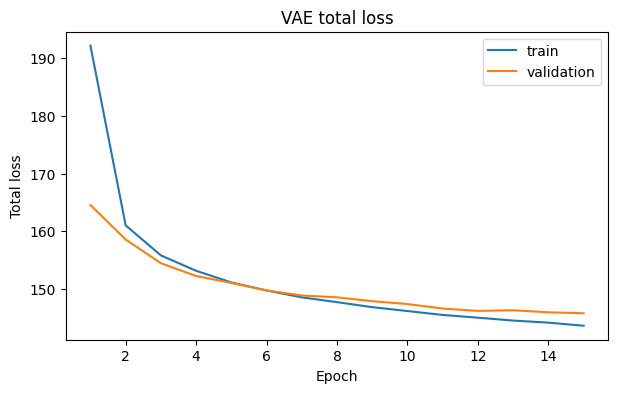

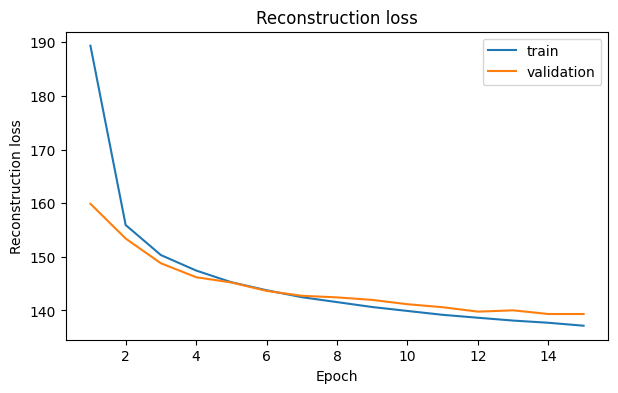

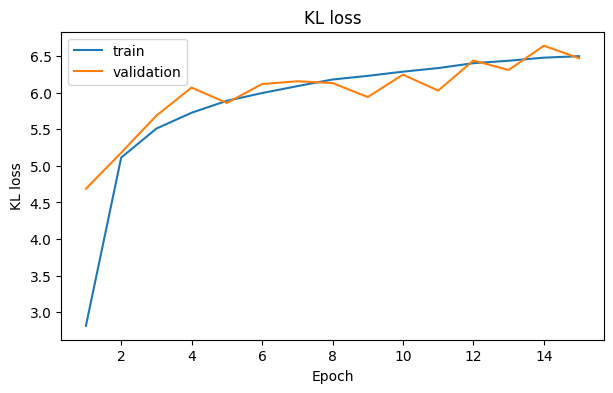

In [9]:
def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_loss"], label="train")
    plt.plot(epochs, history["val_loss"], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel("Total loss")
    plt.title("VAE total loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_recon"], label="train")
    plt.plot(epochs, history["val_recon"], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel("Reconstruction loss")
    plt.title("Reconstruction loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_kl"], label="train")
    plt.plot(epochs, history["val_kl"], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel("KL loss")
    plt.title("KL loss")
    plt.legend()
    plt.show()


plot_history(history)

# 9. Visualize reconstructions

We now compare original images with their reconstructions.

The top row shows the real input images:

$$
x_i
$$

The bottom row shows the reconstructed images:

$$
\hat{x}_i
$$

Good reconstructions mean the decoder can map latent samples back into meaningful data space.

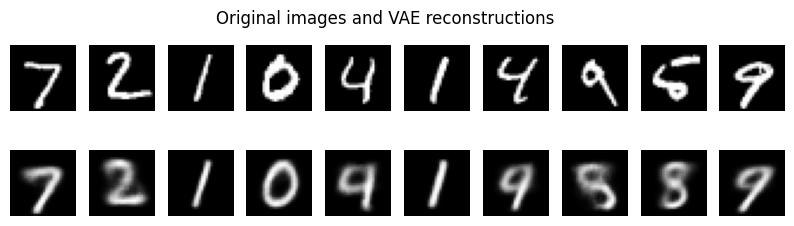

In [10]:
@torch.no_grad()
def plot_reconstructions(model, loader, device="cpu", n=10):
    model.eval()

    x, y = next(iter(loader))
    x = x.to(device)

    x_hat, mu, logvar, z = model(x)

    x = x.cpu()
    x_hat = x_hat.view(-1, 1, 28, 28).cpu()

    n = min(n, x.size(0))

    plt.figure(figsize=(n, 2.5))

    for i in range(n):
        # Original
        plt.subplot(2, n, i + 1)
        plt.imshow(x[i, 0], cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel("Original")

        # Reconstruction
        plt.subplot(2, n, n + i + 1)
        plt.imshow(x_hat[i, 0], cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel("Recon")

    plt.suptitle("Original images and VAE reconstructions")
    plt.show()


plot_reconstructions(model, test_loader, device=device, n=10)

# 10. Visualize the latent space

Because we chose:

$$
\dim(z)=2
$$

we can plot the latent mean for each test image.

For each image \(x_i\), we compute:

$$
\mu_i = q_\phi^\mu(x_i)
$$

and plot $$ \mu_i $$ in 2D.

Color indicates the digit label.

The labels are not used for training. They are only used for visualization.

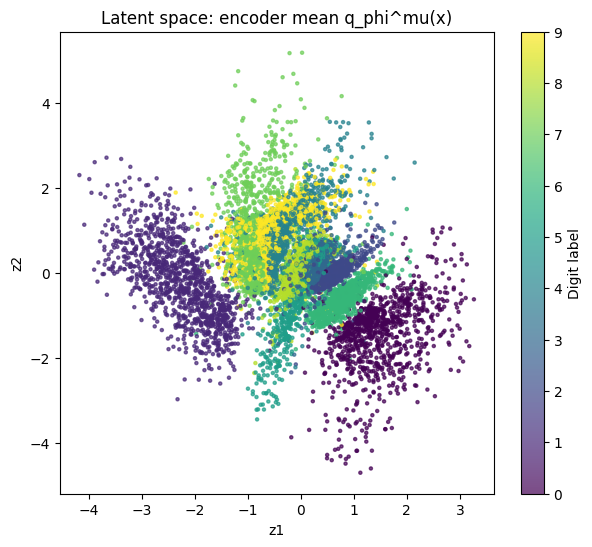

In [11]:
@torch.no_grad()
def collect_latent_means(model, loader, device="cpu"):
    model.eval()

    all_mu = []
    all_labels = []

    for x, y in loader:
        x = x.to(device)
        x_flat = x.view(x.size(0), -1)

        mu, logvar = model.encode(x_flat)

        all_mu.append(mu.cpu())
        all_labels.append(y)

    all_mu = torch.cat(all_mu, dim=0).numpy()
    all_labels = torch.cat(all_labels, dim=0).numpy()

    return all_mu, all_labels


latent_mu, labels = collect_latent_means(model, test_loader, device=device)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    latent_mu[:, 0],
    latent_mu[:, 1],
    c=labels,
    s=5,
    alpha=0.7,
)
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Latent space: encoder mean q_phi^mu(x)")
plt.colorbar(scatter, label="Digit label")
plt.show()

# 11. Generate new images from the prior

A VAE is generative.

After training, we do not need an input image.

We can sample directly from the prior:

$$
z_{\mathrm{new}}\sim p(z)=\mathcal{N}(0,I)
$$

Then decode:

$$
x_{\mathrm{new}}\sim p_\theta(x\mid z_{\mathrm{new}})
$$

In code, we usually use the decoder output as the generated image.

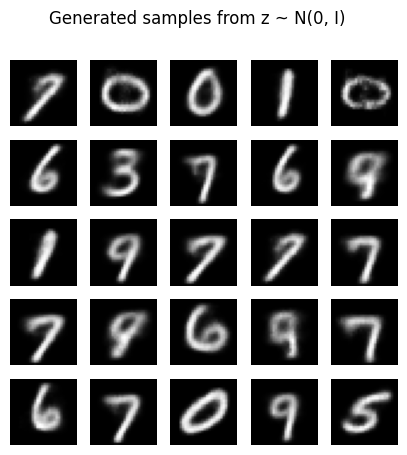

In [14]:
@torch.no_grad()
def generate_samples(model, device="cpu", n=25):
    model.eval()

    z = torch.randn(n, model.latent_dim).to(device)

    x_gen = model.decode(z)
    x_gen = x_gen.view(-1, 1, 28, 28).cpu()

    grid_size = int(np.sqrt(n))

    plt.figure(figsize=(grid_size, grid_size))

    for i in range(n):
        plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(x_gen[i, 0], cmap="gray")
        plt.axis("off")

    plt.suptitle("Generated samples from z ~ N(0, I)")
    plt.show()


generate_samples(model, device=device, n=25)

# 12. Decode a latent grid

Because the latent space is 2D, we can scan across it.

For many values of:

$$ 
z=(z_1,z_2)
$$

we decode:

$$
z \rightarrow \hat{x}
$$

This shows how the VAE organizes digits across the latent space.

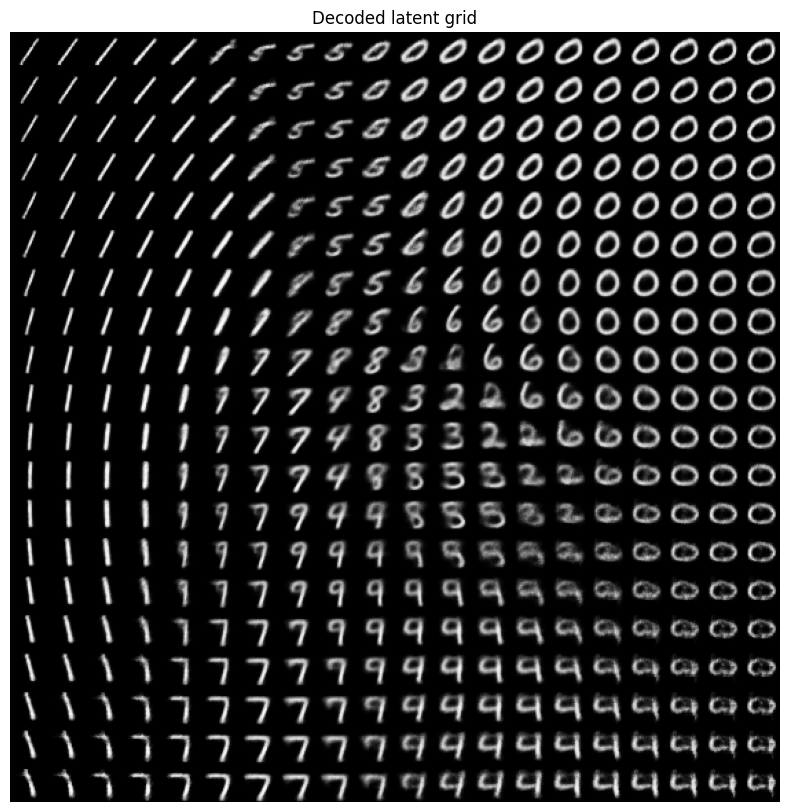

In [15]:
@torch.no_grad()
def plot_latent_grid(model, device="cpu", grid_size=20, z_min=-3, z_max=3):
    model.eval()

    z1_values = np.linspace(z_min, z_max, grid_size)
    z2_values = np.linspace(z_min, z_max, grid_size)

    canvas = np.zeros((28 * grid_size, 28 * grid_size))

    for i, z2 in enumerate(z2_values):
        for j, z1 in enumerate(z1_values):
            z = torch.tensor([[z1, z2]], dtype=torch.float32).to(device)

            x_hat = model.decode(z)
            img = x_hat.view(28, 28).cpu().numpy()

            row = i * 28
            col = j * 28

            canvas[row:row + 28, col:col + 28] = img

    plt.figure(figsize=(10, 10))
    plt.imshow(canvas, cmap="gray")
    plt.axis("off")
    plt.title("Decoded latent grid")
    plt.show()


plot_latent_grid(model, device=device, grid_size=20, z_min=-3, z_max=3)